<a href="https://colab.research.google.com/github/alansiny/INTERSHIP-AI-ML/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Missing Values:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Summary Statistics:
              crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis       

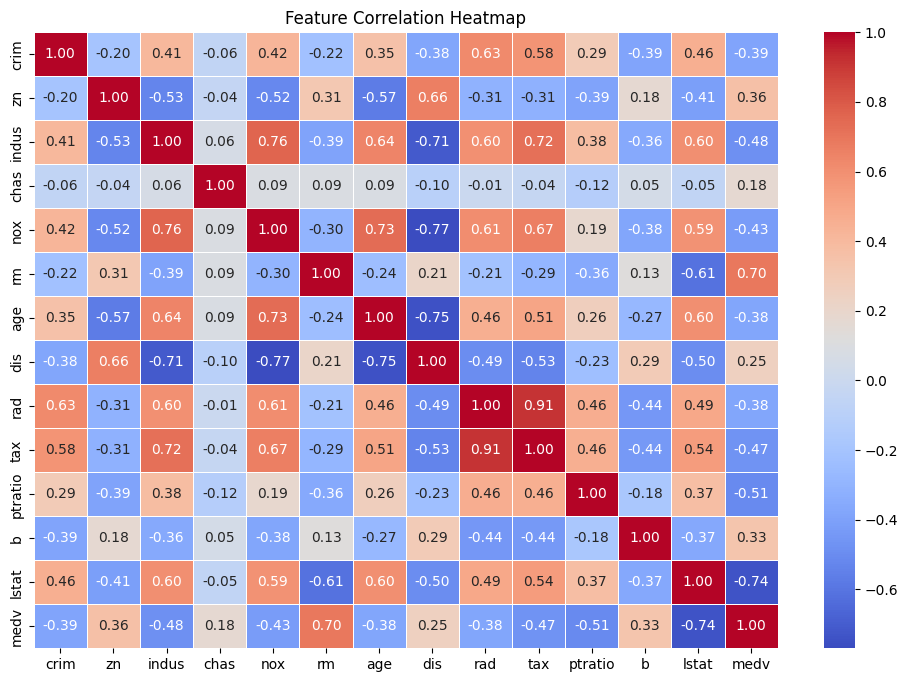

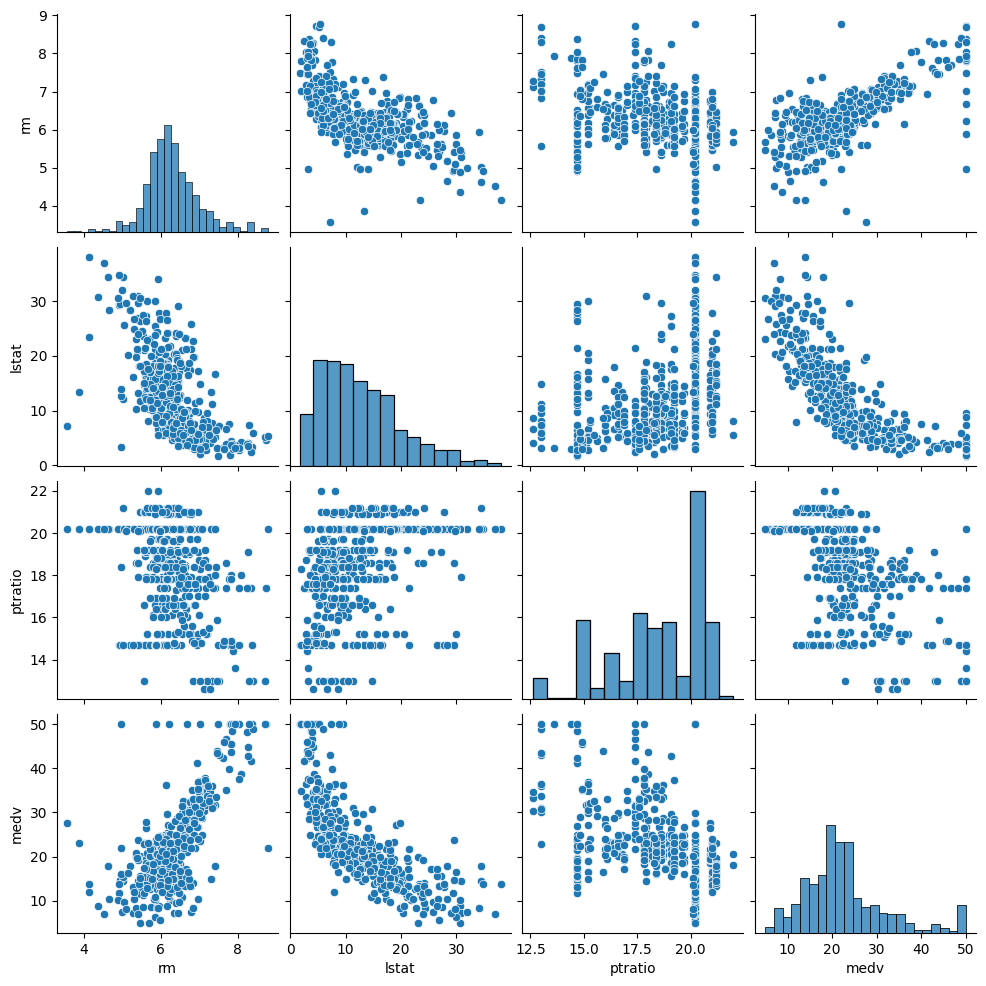

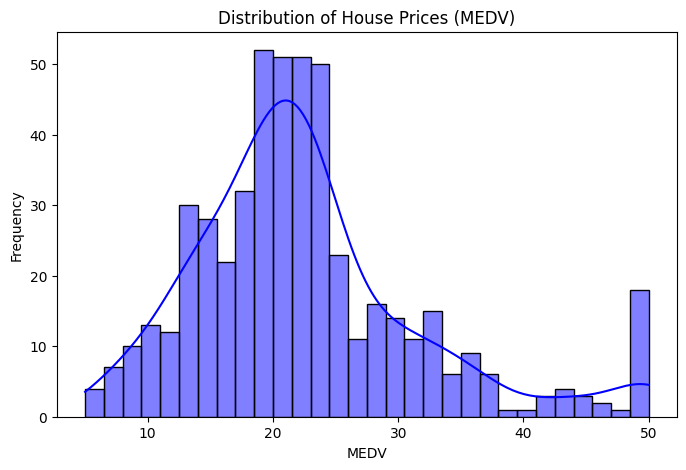

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/boston.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['medv'], bins=30, kde=True, color='blue')
plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
X=df.drop(columns=['medv'])
y=df['medv']

In [6]:


model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print("R2 score:",r2)
print("RMSE:",rmse)

R2 score: 0.6687594935356326
RMSE: 4.928602182665332


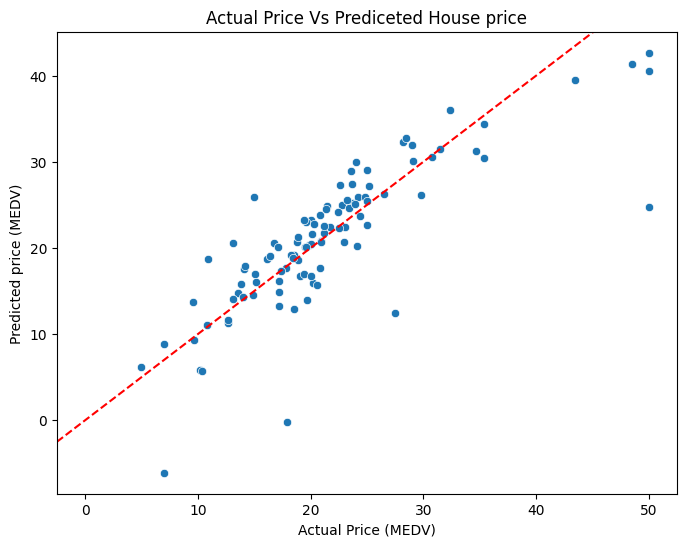

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.title("Actual Price Vs Prediceted House price")
plt.xlabel("Actual Price (MEDV)")
plt.ylabel("Predicted price (MEDV)")
plt.axline([0,0],[1,1],color='red',linestyle="--")

In [11]:
from scipy.stats import skew

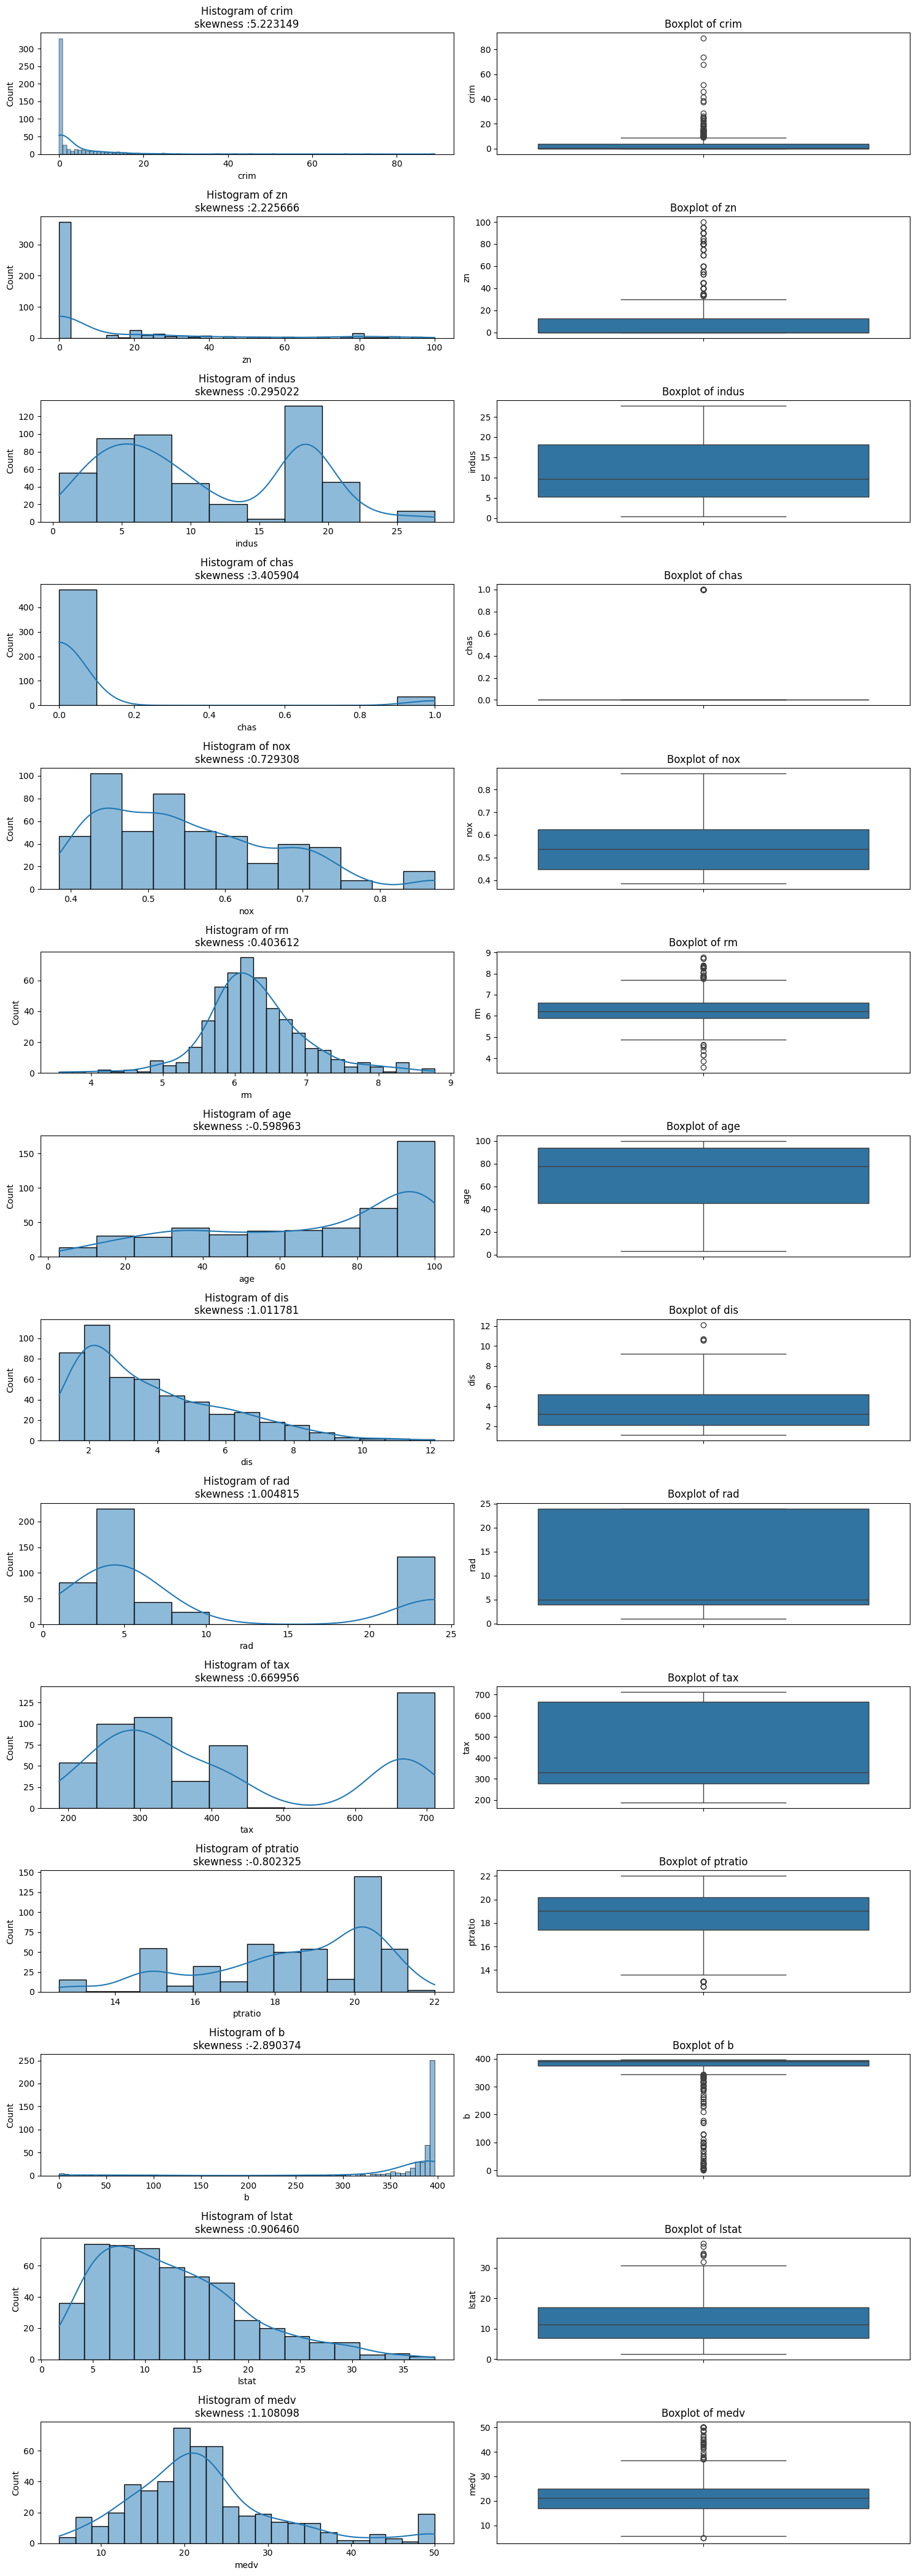

In [12]:
skewness=df.skew()

nums_cols=len(df.columns)
plt.figure(figsize=(15,nums_cols*3))


for i, col in enumerate(df.columns):
  plt.subplot(nums_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}\nskewness :{skewness[col]:2f}")

  plt.subplot(nums_cols,2,2*i+2)
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [13]:
df.skew()

,0
crim,5.223149
zn,2.225666
indus,0.295022
chas,3.405904
nox,0.729308
rm,0.403612
age,-0.598963
dis,1.011781
rad,1.004815
tax,0.669956


In [14]:
import numpy as np


In [16]:
skewed_cols=df.skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly skewed Columns\n",highly_skewed)
print("Negatively skewed Columns\n",negatively_skewed)

Highly skewed Columns
 Index(['crim', 'zn', 'chas', 'dis', 'rad', 'b', 'medv'], dtype='object')
Negatively skewed Columns
 Index(['indus', 'nox', 'rm', 'age', 'tax', 'ptratio', 'lstat'], dtype='object')


In [17]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [18]:
from sklearn.preprocessing import PowerTransformer

In [19]:
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [22]:
X=df.drop(columns=['medv'])
y=df['medv']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print("R2 score:",r2)
print("RMSE:",rmse)

R2 score: 0.7554677765706578
RMSE: 0.18416301100060217


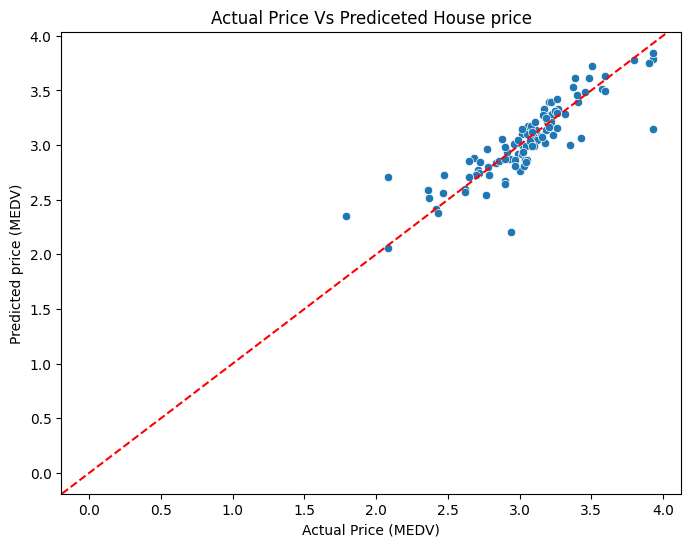

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.title("Actual Price Vs Prediceted House price")
plt.xlabel("Actual Price (MEDV)")
plt.ylabel("Predicted price (MEDV)")
plt.axline([0,0],[1,1],color="red",linestyle="--")

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print('r2 ',r2)
print('rmse ',rmse)

r2  0.8409499057793878
rmse  0.14852560288069508
